使用随机森林进行判断

In [7]:
# c:\Users\Administrator\AppData\Local\Programs\Python\Python312\python.exe -m pip install tensorflow
import sys
print(sys.executable)
import pandas as pd
import numpy as np
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split,StratifiedGroupKFold
from sklearn.model_selection import GroupShuffleSplit
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score,log_loss,roc_curve,auc
#solid
positive_df=pd.read_csv("Solid_1_final.csv")
negative_df=pd.read_csv("Solid_0_final.csv")
positive_df['label']=1
negative_df['label']=0
train_full=pd.concat([positive_df,negative_df],axis=0,ignore_index=True)

c:\Users\Administrator\AppData\Local\Programs\Python\Python312\python.exe


第 1 折 -> Val Loss: 0.5216, Val Acc: 0.7489
第 2 折 -> Val Loss: 0.5129, Val Acc: 0.7532
第 3 折 -> Val Loss: 0.5286, Val Acc: 0.7381
第 4 折 -> Val Loss: 0.5369, Val Acc: 0.7381
第 5 折 -> Val Loss: 0.4944, Val Acc: 0.7619


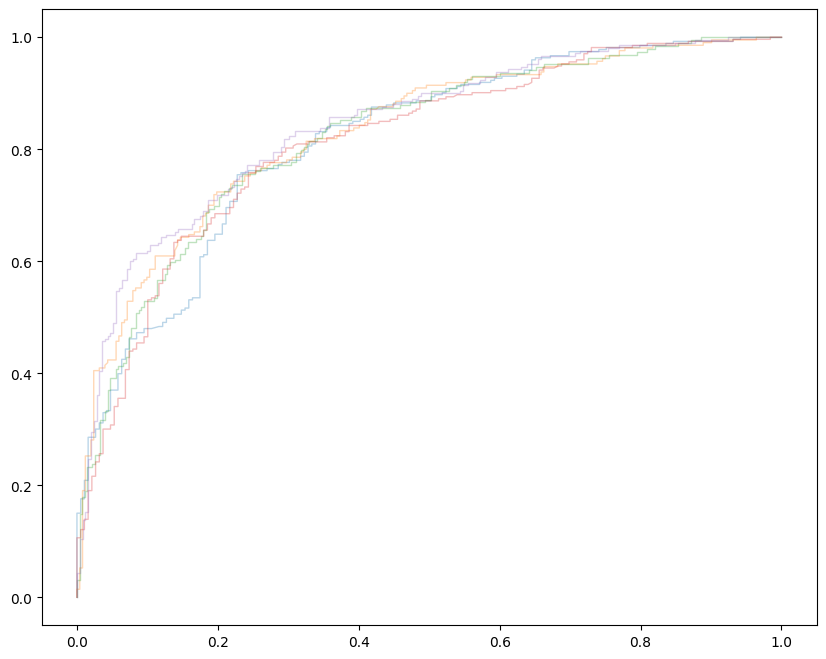

In [8]:
#特征列
ignore_cols = ['Unnamed: 0', 'Name', 'ELO', 'label']
feature_cols = [col for col in train_full.columns if col not in ignore_cols]
train_full[feature_cols] = train_full[feature_cols].fillna(0)
#下面的要换的
pc1_cols=['CenterControlScore', 'pawn_1LifeRatio', 'PieceActivityScore', 'KingDiagonalExposureScore','pawn_2LifeRatio', 
          'KingSafetyScore', 'KingZoneControlScore', 'queen_1LifeRatio', 
          #'rook_1LifeRatio','rook_2LifeRatio', 'bishop_1LifeRatio','bishop_2LifeRatio', knight_2LifeRatio','pawn_8LifeRatio',
          'knight_1LifeRatio', 'pawn_3LifeRatio',
         'KingEscapeSquaresScore', 'AveragePawnAdvanceDepth']
X_full = train_full[pc1_cols].values
y_full = train_full['label'].values
groups = train_full['Name'].values
#交叉验证
cv=StratifiedGroupKFold(n_splits=5,shuffle=True,random_state=42)
fold_num=1
all_val_loss=[]
all_val_acc=[]
        
trained_models=[]
fold_aucs=[]
fold_feature_importances=[]
mean_fpr=np.linspace(0,1,100)
tprs=[]
plt.figure(figsize=(10,8))

for train_idx,val_idx in cv.split(X_full,y_full,groups=groups):
    X_train,X_val=X_full[train_idx],X_full[val_idx]
    y_train,y_val=y_full[train_idx],y_full[val_idx]
    #数据标准化
    scaler=StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_val = scaler.transform(X_val)
    model=RandomForestClassifier(n_estimators=200,max_depth=15,n_jobs=1,random_state=42)
    model.fit(X_train,y_train)
    y_pred_prob=model.predict_proba(X_val)[:,1]
    val_loss=log_loss(y_val,y_pred_prob)
    val_acc=accuracy_score(y_val,(y_pred_prob>0.5).astype(int))
    print(f"第 {fold_num} 折 -> Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}")

    #ROC
    fpr,tpr,thresholds=roc_curve(y_val,y_pred_prob)
    roc_auc=auc(fpr,tpr)
    fold_aucs.append(roc_auc)
    plt.plot(fpr,tpr,lw=1,alpha=0.3,label=f'ROC fold {fold_num} (AUC = {roc_auc:.2f})')
    interp_tpr = np.interp(mean_fpr, fpr, tpr)
    interp_tpr[0] = 0.0
    tprs.append(interp_tpr)

    fold_feature_importances.append(model.feature_importances_)

    trained_models.append((model,scaler))
    fold_num+=1

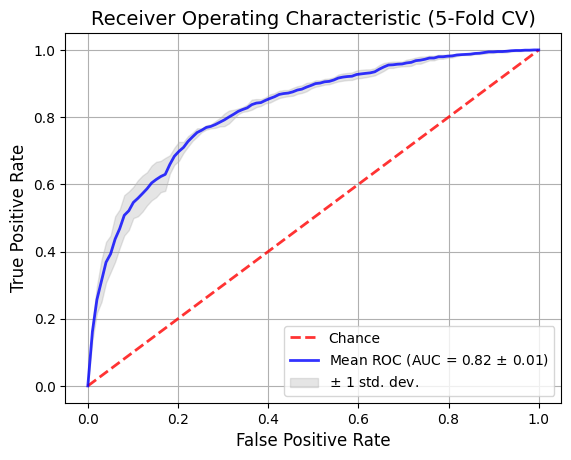

In [10]:
plt.plot([0,1],[0,1],linestyle='--',lw=2,color='r',label='Chance',alpha=.8)
mean_tpr=np.mean(tprs,axis=0)
mean_tpr[-1]=1.0
mean_auc=auc(mean_fpr,mean_tpr)
std_auc=np.std(fold_aucs)
plt.plot(mean_fpr, mean_tpr, color='b',
         label=r'Mean ROC (AUC = %0.2f $\pm$ %0.2f)' % (mean_auc, std_auc),
         lw=2, alpha=.8)
std_tpr = np.std(tprs, axis=0)
tprs_upper = np.minimum(mean_tpr + std_tpr, 1)
tprs_lower = np.maximum(mean_tpr - std_tpr, 0)
plt.fill_between(mean_fpr, tprs_lower, tprs_upper, color='grey', alpha=.2,
                 label=r'$\pm$ 1 std. dev.')

plt.xlim([-0.05, 1.05])
plt.ylim([-0.05, 1.05])
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('Receiver Operating Characteristic (5-Fold CV)', fontsize=14)
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

In [18]:
avg_importance = np.mean(fold_feature_importances, axis=0)
feat_imp_df = pd.DataFrame({
    'Feature': pc1_cols, 
    'Importance': avg_importance
})
top_features = feat_imp_df.sort_values(by='Importance', ascending=False)

print("特征重要性排名 (Feature Importance)")
for i, (index, row) in enumerate(top_features.iterrows()):
    print(f"No.{i+1} {row['Feature']:<25} : {row['Importance']:.4f}")

特征重要性排名 (Feature Importance)
No.1 queen_1LifeRatio          : 0.1317
No.2 KingSafetyScore           : 0.1243
No.3 KingEscapeSquaresScore    : 0.1136
No.4 PieceActivityScore        : 0.1067
No.5 pawn_3LifeRatio           : 0.0768
No.6 KingZoneControlScore      : 0.0767
No.7 pawn_2LifeRatio           : 0.0666
No.8 CenterControlScore        : 0.0617
No.9 knight_1LifeRatio         : 0.0613
No.10 KingDiagonalExposureScore : 0.0612
No.11 pawn_1LifeRatio           : 0.0606
No.12 AveragePawnAdvanceDepth   : 0.0588


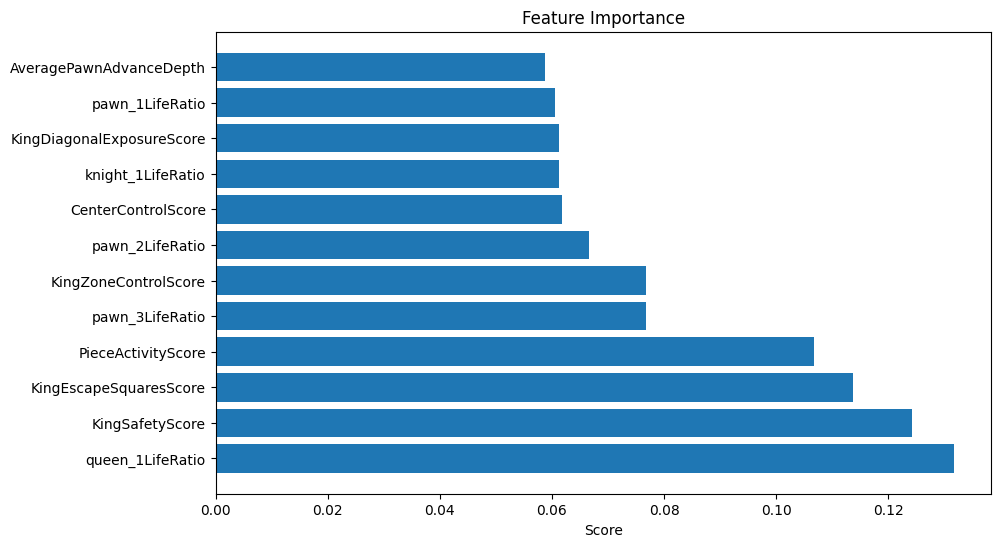

In [20]:
plt.figure(figsize=(10, 6)) 
plt.barh(top_features['Feature'], top_features['Importance']) 
plt.title('Feature Importance')
plt.xlabel('Score') 
plt.show()